In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dos = pd.read_csv('DDOS.pcap_ISCX.csv')
dos

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,192.168.10.15-72.21.91.29-61374-80-6,72.21.91.29,80,192.168.10.15,61374,6,7/7/2017 5:02,61,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,192.168.10.15-72.21.91.29-61378-80-6,72.21.91.29,80,192.168.10.15,61378,6,7/7/2017 5:02,72,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,192.168.10.15-72.21.91.29-61375-80-6,72.21.91.29,80,192.168.10.15,61375,6,7/7/2017 5:02,75,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,192.168.10.15-8.41.222.187-61323-80-6,8.41.222.187,80,192.168.10.15,61323,6,7/7/2017 5:02,48,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
dos.shape

(225745, 85)

In [ ]:
dos.head(10)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,192.168.10.5-104.20.10.120-54871-443-6,104.20.10.120,443,192.168.10.5,54871,6,7/7/2017 3:30,1022,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443,192.168.10.5,54925,6,7/7/2017 3:30,4,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443,192.168.10.5,54925,6,7/7/2017 3:30,42,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,192.168.10.8-104.28.13.116-9282-443-6,104.28.13.116,443,192.168.10.8,9282,6,7/7/2017 3:30,4,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,192.168.10.5-104.97.123.193-55153-443-6,104.97.123.193,443,192.168.10.5,55153,6,7/7/2017 3:30,4,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
dos.tail(10)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
225735,192.168.10.15-52.84.145.216-61301-80-6,52.84.145.216,80,192.168.10.15,61301,6,7/7/2017 5:02,28,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225736,192.168.10.17-52.84.145.38-38130-443-6,52.84.145.38,443,192.168.10.17,38130,6,7/7/2017 5:02,45,1,1,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225737,192.168.10.8-72.21.81.253-10398-443-6,72.21.81.253,443,192.168.10.8,10398,6,7/7/2017 5:02,4,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225738,192.168.10.15-72.21.91.29-61376-80-6,72.21.91.29,80,192.168.10.15,61376,6,7/7/2017 5:02,44,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225739,192.168.10.15-72.21.91.29-61377-80-6,72.21.91.29,80,192.168.10.15,61377,6,7/7/2017 5:02,26,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225740,192.168.10.15-72.21.91.29-61374-80-6,72.21.91.29,80,192.168.10.15,61374,6,7/7/2017 5:02,61,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,192.168.10.15-72.21.91.29-61378-80-6,72.21.91.29,80,192.168.10.15,61378,6,7/7/2017 5:02,72,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,192.168.10.15-72.21.91.29-61375-80-6,72.21.91.29,80,192.168.10.15,61375,6,7/7/2017 5:02,75,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,192.168.10.15-8.41.222.187-61323-80-6,8.41.222.187,80,192.168.10.15,61323,6,7/7/2017 5:02,48,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225744,192.168.10.15-8.43.72.21-61326-80-6,8.43.72.21,80,192.168.10.15,61326,6,7/7/2017 5:02,68,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:

dos.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [ ]:
dos.columns=dos.columns.str.strip()

In [ ]:
dos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225745 non-null  object 
 1   Source IP                    225745 non-null  object 
 2   Source Port                  225745 non-null  int64  
 3   Destination IP               225745 non-null  object 
 4   Destination Port             225745 non-null  int64  
 5   Protocol                     225745 non-null  int64  
 6   Timestamp                    225745 non-null  object 
 7   Flow Duration                225745 non-null  int64  
 8   Total Fwd Packets            225745 non-null  int64  
 9   Total Backward Packets       225745 non-null  int64  
 10  Total Length of Fwd Packets  225745 non-null  int64  
 11  Total Length of Bwd Packets  225745 non-null  int64  
 12  Fwd Packet Length Max        225745 non-null  int64  
 13 

In [ ]:
dos.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.000000,225745.00000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,38257.568402,8879.61946,7.600288,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,23057.302075,19754.64740,3.881586,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.000000,0.00000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,18990.000000,80.00000,6.000000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,49799.000000,80.00000,6.000000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,58296.000000,80.00000,6.000000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65534.000000,65532.00000,17.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


In [ ]:
dos.groupby("Label").count()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,97718,97718,97718,97718,97718,97718,97718,97718,97718,97718,...,97718,97718,97718,97718,97718,97718,97718,97718,97718,97718
DDoS,128027,128027,128027,128027,128027,128027,128027,128027,128027,128027,...,128027,128027,128027,128027,128027,128027,128027,128027,128027,128027


In [ ]:
dos["Label"].value_counts()

,count
Label,
DDoS,128027
BENIGN,97718


<Axes: xlabel='Label', ylabel='count'>

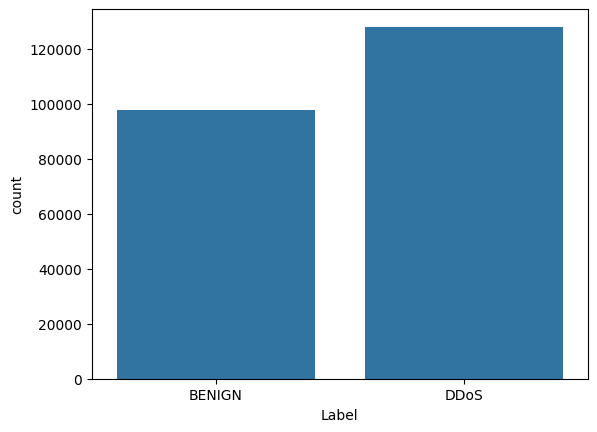

In [ ]:
sns.countplot(x=dos['Label'])

In [ ]:
dos.loc[:,'Label'].unique()

array(['BENIGN', 'DDoS'], dtype=object)

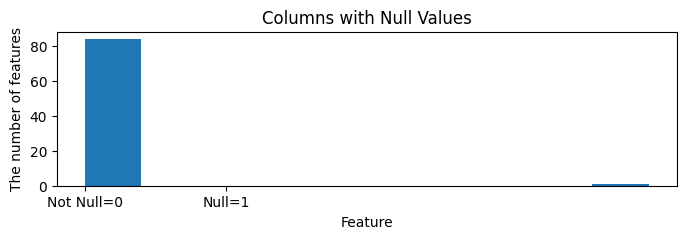

In [ ]:
#Checking the null values in the dataset.
plt.figure(1,figsize=( 8,2))
plt.hist( dos.isna().sum())
plt.xticks([0, 1], labels=['Not Null=0', 'Null=1'])
plt.title('Columns with Null Values')
plt.xlabel('Feature')
plt.ylabel('The number of features')
plt.show()

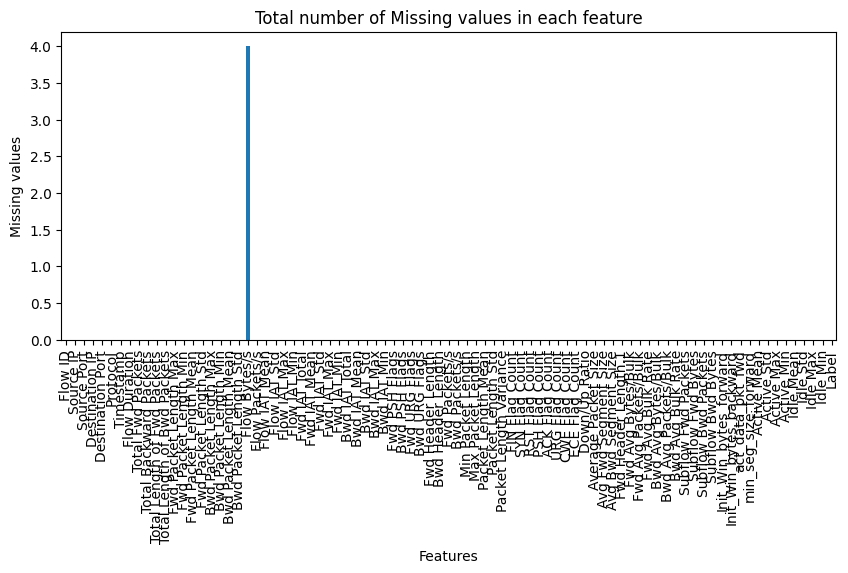

In [ ]:
def plotMissingValues(dataframe):
    missing_values = dataframe.isnull().sum()  # Counting null values for each column
    fig = plt.figure(figsize=(10,4))
    missing_values.plot(kind='bar')
    plt.xlabel("Features")
    plt.ylabel("Missing values")
    plt.title("Total number of Missing values in each feature")
    plt.show()
plotMissingValues(dos)

In [ ]:
missing_percentage = dos.isnull().mean() * 100
print(missing_percentage)


Flow ID             0.0
Source IP           0.0
Source Port         0.0
Destination IP      0.0
Destination Port    0.0
                   ... 
Idle Mean           0.0
Idle Std            0.0
Idle Max            0.0
Idle Min            0.0
Label               0.0
Length: 85, dtype: float64


In [ ]:
dos=dos.dropna()

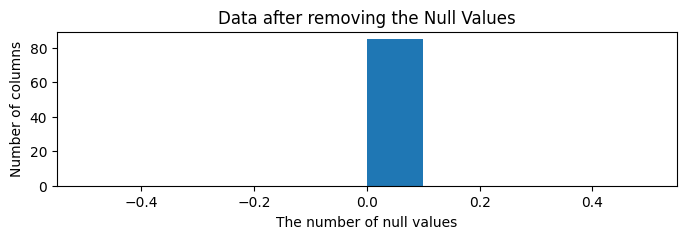

In [ ]:
#Checking the null values in the dataset.
plt.figure(1,figsize=( 8,2))
plt.hist( dos.isna().sum())
plt.title('Data after removing the Null Values')
plt.xlabel('The number of null values')
plt.ylabel('Number of columns')
plt.show()

In [ ]:
pd.set_option('use_inf_as_na', True)  # Treat inf as NaN
null_values=dos.isnull().sum()  # Check for NaN values

In [ ]:
dos=dos.dropna()

In [ ]:
# To know the data types of the columns
(dos.dtypes=='object')

,0
Flow ID,True
Source IP,True
Source Port,False
Destination IP,True
Destination Port,False
...,...
Idle Mean,False
Idle Std,False
Idle Max,False
Idle Min,False


In [ ]:
# Converting the labels in the DataFrame to numerical values
dos['Label'] = dos['Label'].map({'BENIGN': 0, 'DDoS': 1})

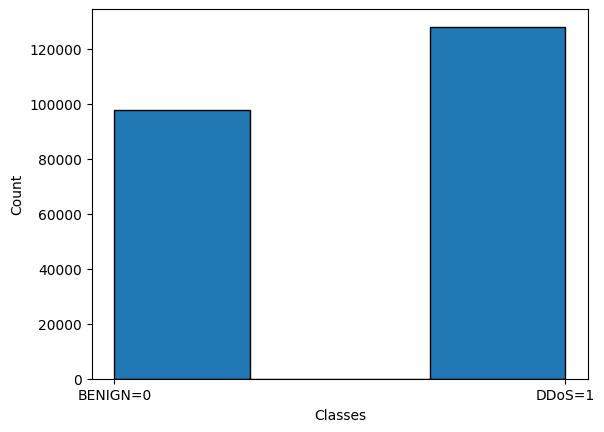

In [ ]:
# Printing the DataFrame
plt.hist(dos['Label'], bins=[0, 0.3,0.7,1], edgecolor='black')  # Specify bins as [0, 1]
plt.xticks([0, 1], labels=['BENIGN=0', 'DDoS=1'])
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

In [ ]:
# Splitting data into features and target variable
X = dos.drop('Label', axis=1)
y = dos['Label']

In [ ]:
dos.loc[:,'Label'].unique()

array([0, 1])

In [ ]:
# Splitting data into features and target variable
X = dos.drop(['Label', 'Flow ID'], axis=1)  # Exclude 'Flow ID' from features
y = dos['Label']

# Identify and select numeric features
numeric_features = X.select_dtypes(include=['number']).columns
X_numeric = X[numeric_features]

# Standardize the numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# If you need to keep the original columns, you can reassign the scaled data back to the original dataframe
X[numeric_features] = X_scaled

In [ ]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: '192.168.10.5-104.16.207.165-54865-443-6'

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# Initialize PCA to reduce to 2 principal components
pca = PCA(n_components=2)

# Fit and transform the data
pca_result = pca.fit_transform(X_scaled)

# Create a DataFrame with the PCA results
pca_df2 = pd.DataFrame(data=pca_result, columns=['Principal Component 1', 'Principal Component 2'])

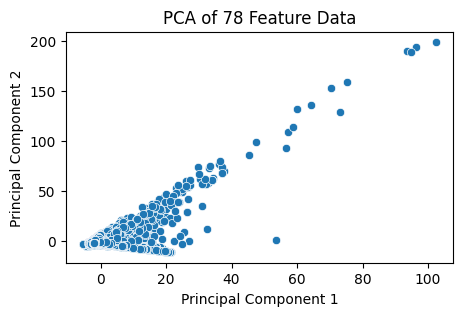

In [ ]:
# Plot the PCA results
plt.figure(figsize=(5,3))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pca_df2)
plt.title('PCA of 78 Feature Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [ ]:
# Initialize PCA
n_components = 10  # Number of principal components to keep
pca = PCA(n_components=n_components)

# Fit and transform the data
principal_components = pca.fit_transform(X)

# Create a DataFrame with the principal components
pca_df1 = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(n_components)])

ValueError: could not convert string to float: '104.16.207.165'

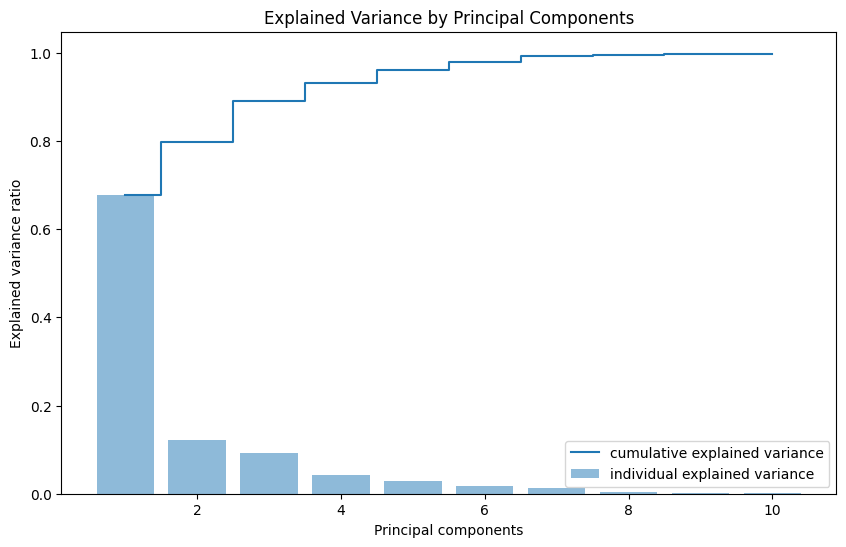

In [ ]:
# Explained variance by each principal component
explained_variance = pca.explained_variance_ratio_

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, n_components + 1), explained_variance, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1, n_components + 1), explained_variance.cumsum(), where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.title('Explained Variance by Principal Components')
plt.show()


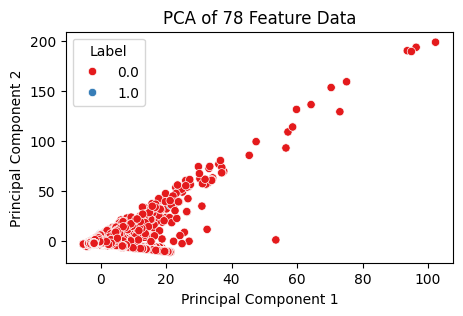

In [ ]:
pca_df2['Label'] = y
plt.figure(figsize=(5,3))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pca_df2, hue='Label', palette='Set1')
plt.title('PCA of 78 Feature Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print("The train dataset size = ",X_train.shape)
print("The test dataset size = ",X_test.shape)

The train dataset size =  (180568, 80)
The test dataset size =  (45143, 80)


**Model Training**

In [ ]:
# logistic regression model
lr = LogisticRegression( penalty='l2')

In [ ]:
lr.learning_rate = 0.1

In [ ]:
# Training the model
lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Making predictions
y_pred = lr.predict(X_test)

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_cm = confusion_matrix(y_test, y_pred)
lr_cr = classification_report(y_test, y_pred)

In [ ]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 99.88%
Test Accuracy: 99.88%


In [ ]:
print('\nLogistic Regression Metrics:')
print(f'Accuracy: {lr_accuracy:.4f}')
print(f'F1 Score: {lr_f1:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall: {lr_recall:.4f}')
print(f'Class Report:',lr_cr)


Logistic Regression Metrics:
Accuracy: 0.9988
F1 Score: 0.9990
Precision: 0.9991
Recall: 0.9988
Class Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19419
           1       1.00      1.00      1.00     25724

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



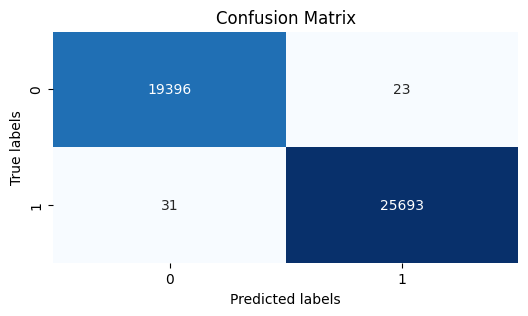

In [ ]:
plt.figure(figsize=(6, 3))
sns.heatmap(lr_cm, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt= DecisionTreeClassifier(criterion='gini',max_depth=None,         # Maximum depth of the tree
    min_samples_split=2,    # Minimum samples required to split an internal node
    min_samples_leaf=1,     # Minimum samples required to be at a leaf node
    max_features=None,
    random_state=42 )

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt.predict(X_test)
y_pred

array([1, 0, 1, ..., 0, 0, 1])

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred)
dt_cm = confusion_matrix(y_test, y_pred)
dt_cr = classification_report(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)

In [ ]:
print('\nDecision Tree Metrics:')
print(f'Accuracy: {dt_accuracy:.4f}')
print(f'F1 Score: {dt_f1:.4f}')
print(f'Precision: {dt_precision:.4f}')
print(f'Recall: {dt_recall:.4f}')
print(f'Class Report:',dt_cr)


Decision Tree Metrics:
Accuracy: 0.9995
F1 Score: 0.9995
Precision: 1.0000
Recall: 0.9990
Class Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6223
           1       1.00      1.00      1.00      7025

    accuracy                           1.00     13248
   macro avg       1.00      1.00      1.00     13248
weighted avg       1.00      1.00      1.00     13248



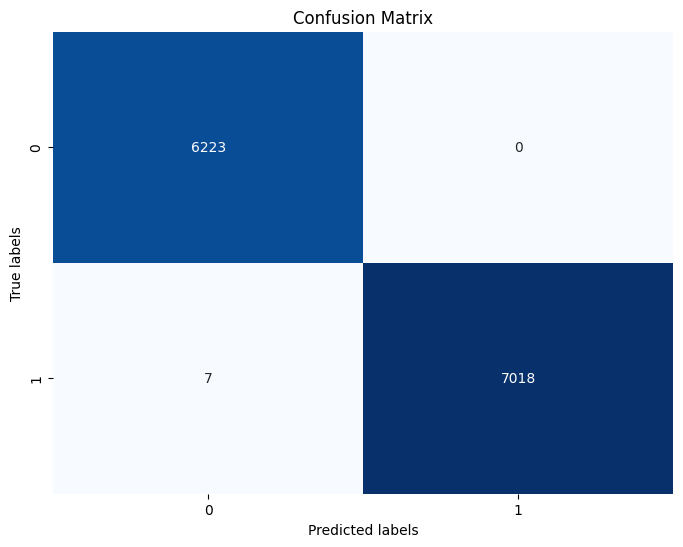

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 100.00%
Test Accuracy: 99.95%


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Initializing KNN classifier
kn = KNeighborsClassifier(n_neighbors=5)

# Training the classifier
kn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = kn.predict(X_test)
y_pred

array([1, 0, 1, ..., 0, 0, 1])

In [ ]:
kn_accuracy = accuracy_score(y_test, y_pred)
kn_cm = confusion_matrix(y_test, y_pred)
kn_cr = classification_report(y_test, y_pred)
kn_f1 = f1_score(y_test, y_pred)
kn_precision = precision_score(y_test, y_pred)
kn_recall = recall_score(y_test, y_pred)

In [ ]:
print('\nKNeighbour Classifier:')
print(f'Accuracy: {kn_accuracy:.4f}')
print(f'F1 Score: {kn_f1:.4f}')
print(f'Precision: {kn_precision:.4f}')
print(f'Recall: {kn_recall:.4f}')
print(f'Class Report:',kn_cr)


KNeighbour Classifier:
Accuracy: 0.9993
F1 Score: 0.9994
Precision: 0.9997
Recall: 0.9990
Class Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6223
           1       1.00      1.00      1.00      7025

    accuracy                           1.00     13248
   macro avg       1.00      1.00      1.00     13248
weighted avg       1.00      1.00      1.00     13248



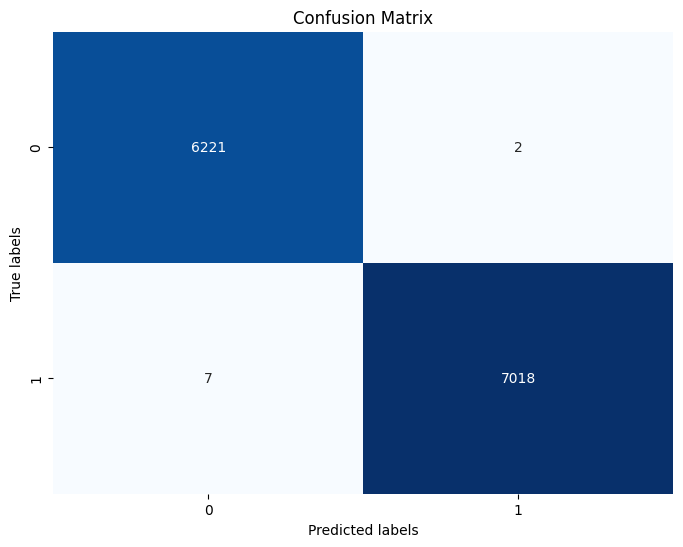

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(kn_cm, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 99.84%
Test Accuracy: 99.79%


**Ensemble Method**

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
# Defining the base models
base_models = [
    ('lr', lr),
    ('dt', dt),
    ('kn',kn)
]

In [ ]:
meta_model = lr

In [ ]:
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

In [ ]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(estimators=[('lr', LogisticRegression()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('kn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [ ]:
y_pred = stacking_clf.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [ ]:
en_accuracy = accuracy_score(y_test, y_pred)
en_cm = confusion_matrix(y_test, y_pred)
en_cr = classification_report(y_test, y_pred)
en_f1 = f1_score(y_test, y_pred)
en_precision = precision_score(y_test, y_pred)
en_recall = recall_score(y_test, y_pred)

In [ ]:
print('\nEnsemble:')
print(f'Accuracy: {en_accuracy:.4f}')
print(f'F1 Score: {en_f1:.4f}')
print(f'Precision: {en_precision:.4f}')
print(f'Recall: {en_recall:.4f}')
print(f'Class Report:',en_cr)


Ensemble:
Accuracy: 0.9994
F1 Score: 0.9994
Precision: 0.9999
Recall: 0.9990
Class Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6223
           1       1.00      1.00      1.00      7025

    accuracy                           1.00     13248
   macro avg       1.00      1.00      1.00     13248
weighted avg       1.00      1.00      1.00     13248



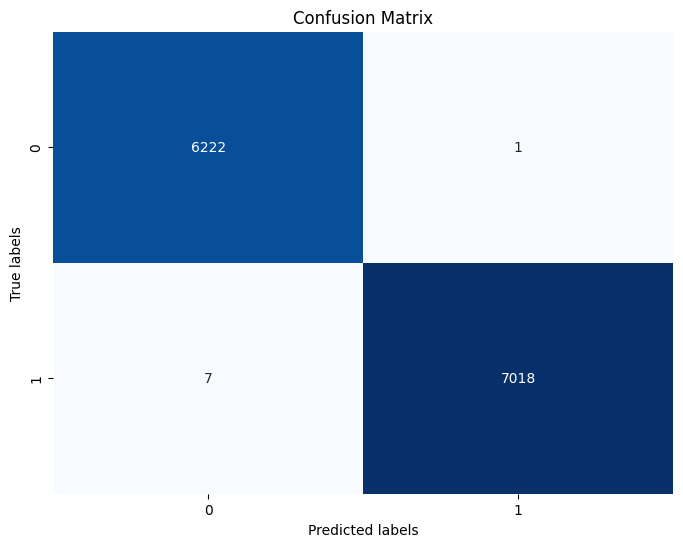

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(en_cm, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

**Deep Learning Model**

In [ ]:
!pip install tensorflow

In [ ]:
#main
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

In [ ]:
# Initializing the neural network model
model = Sequential()

In [ ]:
# Adding input layer (specify input dimensions)
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())  # Adding Batch Normalization after activation
model.add(Dropout(0.5))  # Adding Dropout layer to reduce overfitting

In [ ]:
# Adding hidden layers
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

In [ ]:
# Adding additional hidden layers
model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

In [ ]:
# Adding output layer (1 neuron for binary classification, sigmoid activation)
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Compiling the model
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
# Printing model summary
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          10,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 332,833 (1.27 MB)

 Trainable params: 329,953 (1.26 MB)

 Non-trainable params: 2,880 (11.25 KB)

None


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.7728 - loss: 6.9125 - val_accuracy: 0.9844 - val_loss: 0.7814
Epoch 2/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9654 - loss: 0.6042 - val_accuracy: 0.9852 - val_loss: 0.2930
Epoch 3/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 61s 30ms/step - accuracy: 0.9717 - loss: 0.3279 - val_accuracy: 0.9854 - val_loss: 0.2774
Epoch 4/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 49s 30ms/step - accuracy: 0.9700 - loss: 0.3227 - val_accuracy: 0.9878 - val_loss: 0.2617
Epoch 5/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 63s 18ms/step - accuracy: 0.9748 - loss: 0.3057 - val_accuracy: 0.9971 - val_loss: 0.2141
Epoch 6/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9720 - loss: 0.3070 - val_accuracy: 0.9851 - val_loss: 0.2541
Epoch 7/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9767 - loss: 0.2912 - val_accuracy: 0.9852 - val_loss: 0.2833
Epoch 8/10
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9750 -

In [ ]:
# Evaluating the model
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)  # Assuming binary classification with threshold 0.5

# Converting y_pred to 1D array
y_pred = y_pred.flatten()

414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [ ]:
nn_accuracy = accuracy_score(y_test, y_pred)
nn_cm = confusion_matrix(y_test, y_pred)
nn_cr = classification_report(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred)
nn_precision = precision_score(y_test, y_pred)
nn_recall = recall_score(y_test, y_pred)

In [ ]:
print('\nNeural Network:')
print(f'Accuracy: {nn_accuracy:.4f}')
print(f'F1 Score: {nn_f1:.4f}')
print(f'Precision: {nn_precision:.4f}')
print(f'Recall: {nn_recall:.4f}')
print(f'Class Report:',nn_cr)


Neural Network:
Accuracy: 0.9881
F1 Score: 0.9889
Precision: 0.9789
Recall: 0.9990
Class Report:               precision    recall  f1-score   support

           0       1.00      0.98      0.99      6223
           1       0.98      1.00      0.99      7025

    accuracy                           0.99     13248
   macro avg       0.99      0.99      0.99     13248
weighted avg       0.99      0.99      0.99     13248



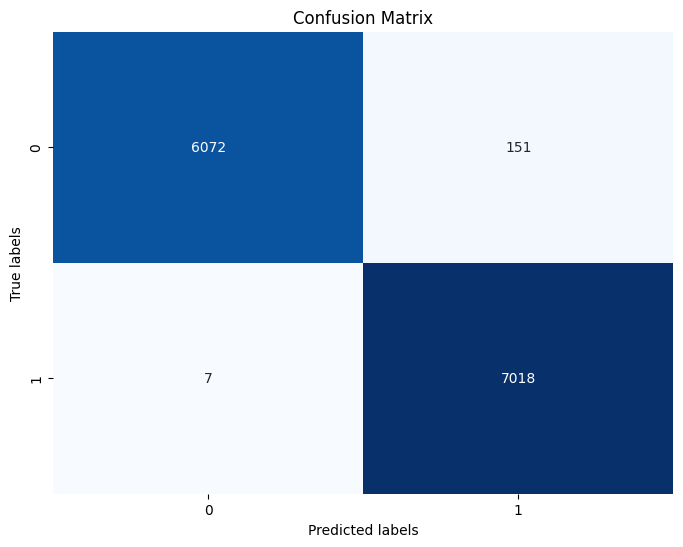

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(nn_cm, annot=True, cmap='Blues', fmt='d', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Convert predictions to binary (0 or 1) based on a threshold (e.g., 0.5)
y_train_pred_binary = (y_train_pred > 0.5).astype(int)
y_test_pred_binary = (y_test_pred > 0.5).astype(int)

# Calculate accuracy scores using binary predictions
train_accuracy = accuracy_score(y_train, y_train_pred_binary)
test_accuracy = accuracy_score(y_test, y_test_pred_binary)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

1656/1656 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
414/414 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Training Accuracy: 98.90%
Test Accuracy: 98.81%
